# World Happiness Report: Exploratory Data Analysis

This notebook performs an exploratory data analysis on the World Happiness Report datasets from 2015 to 2019, examining factors that contribute to happiness scores across different countries.

### Load Data

We begin by importing essential libraries for data manipulation and visualization, then load the World Happiness Report datasets for each year from 2015 to 2019.

In [2]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


# Load the dataset
df_2015 = pd.read_csv('data/2015.csv')
df_2016 = pd.read_csv('data/2016.csv')
df_2017 = pd.read_csv('data/2017.csv')
df_2018 = pd.read_csv('data/2018.csv')
df_2019 = pd.read_csv('data/2019.csv')


### ***Pre-EDA***

Before diving into analysis, we perform preliminary exploratory data analysis (Pre-EDA) to understand the structure and content of each dataset.

In [3]:
# Display the first few rows of each dataset
print("2015 Dataset:")
display(df_2015.head(3))
print("\n2016 Dataset:")
display(df_2016.head(3))
print("\n2017 Dataset:")
display(df_2017.head(3))
print("\n2018 Dataset:")
display(df_2018.head(3))
print("\n2019 Dataset:")
display(df_2019.head(3))



2015 Dataset:


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204



2016 Dataset:


,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137



2017 Dataset:


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715



2018 Dataset:


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408



2019 Dataset:


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341


In [4]:
# Display the columns of each dataset

print("2015 Dataset Columns:")
print(df_2015.columns.tolist())
print("\n2016 Dataset Columns:")
print(df_2016.columns.tolist())
print("\n2017 Dataset Columns:")
print(df_2017.columns.tolist())
print("\n2018 Dataset Columns:")
print(df_2018.columns.tolist())
print("\n2019 Dataset Columns:")
print(df_2019.columns.tolist())


2015 Dataset Columns:
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

2016 Dataset Columns:
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

2017 Dataset Columns:
['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

2018 Dataset Columns:
['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

2019 Dataset C

### Standardize Dataframes' Columns 

Since the datasets from different years have varying column names, we standardize them by selecting relevant columns and renaming them to consistent names for easier comparison and analysis.

In [5]:
# Select relevant columns for analysis
df_2015_std =df_2015[['Country',  'Happiness Score','Economy (GDP per Capita)',
                 'Family','Health (Life Expectancy)', 'Freedom',
                  'Trust (Government Corruption)','Generosity']]
df_2016_std =df_2016[['Country',  'Happiness Score','Economy (GDP per Capita)',
                 'Family','Health (Life Expectancy)', 'Freedom',
                  'Trust (Government Corruption)','Generosity']]

df_2017_std =df_2017[['Country',  'Happiness.Score','Economy..GDP.per.Capita.',
                 'Family','Health..Life.Expectancy.', 'Freedom',
                  'Trust..Government.Corruption.','Generosity']]

df_2018_std =df_2018[['Country or region',  'Score','GDP per capita',
                 'Social support','Healthy life expectancy', 'Freedom to make life choices',
                  'Perceptions of corruption','Generosity']]
df_2019_std =df_2019[['Country or region',  'Score','GDP per capita',
                 'Social support','Healthy life expectancy', 'Freedom to make life choices',
                  'Perceptions of corruption','Generosity']]


# Rename columns for consistency
df_2015_std.columns = ['Country', 'Score', 'GDP_per_Capita', 'Family_Support','Life_Expectancy',
                       'Freedom', 'Corruption_Perception', 'Generosity']

df_2016_std.columns = ['Country', 'Score', 'GDP_per_Capita', 'Family_Support','Life_Expectancy',
                       'Freedom', 'Corruption_Perception', 'Generosity']

df_2017_std.columns = ['Country', 'Score', 'GDP_per_Capita', 'Family_Support','Life_Expectancy',
                       'Freedom', 'Corruption_Perception', 'Generosity']

df_2018_std.columns = ['Country', 'Score', 'GDP_per_Capita', 'Family_Support','Life_Expectancy',
                       'Freedom', 'Corruption_Perception', 'Generosity']

df_2019_std.columns = ['Country', 'Score', 'GDP_per_Capita', 'Family_Support','Life_Expectancy',
                       'Freedom', 'Corruption_Perception', 'Generosity']


In [6]:
# add year column to each dataset
df_2015_std['Year'] = 2015
df_2016_std['Year'] = 2016
df_2017_std['Year'] = 2017
df_2018_std['Year'] = 2018
df_2019_std['Year'] = 2019

### Combining Datasets
In this section, we combine all the standardized datasets from different years into a single DataFrame for unified analysis.

In [7]:
# Combine all datasets into a single DataFrame
df=pd.concat([df_2015_std,df_2016_std,df_2017_std,df_2018_std,df_2019_std],ignore_index=True)

# Display the combined dataset
print("Combined Dataset:")
display(df.head(5))


Combined Dataset:


,Country,Score,GDP_per_Capita,Family_Support,Life_Expectancy,Freedom,Corruption_Perception,Generosity,Year
0,Switzerland,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


### Exploratory Data Analysis
Now that we have a combined dataset, we can perform exploratory data analysis to uncover patterns, correlations, and insights from the World Happiness Report data.

In [8]:
# Functions
def bar_plot(labels, values, title, xlabel, ylabel,
             annotate=False, orient='v', palette='viridis'):
    
    plt.figure(figsize=(10,6))
    
    if orient == 'v':
        ax = sns.barplot(x=labels, y=values, palette=palette)
    else:
        ax = sns.barplot(x=values, y=labels, palette=palette)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    

    if annotate:
        for i, v in enumerate(values):
            if orient == 'v':
                ax.text(i, v + 0.02, f"{v:.2f}", ha='center')
            else:
                ax.text(v + 0.02, i, f"{v:.2f}", va='center')

    plt.tight_layout()
    plt.show()
    

In [9]:
# display the shape of the combined dataset
print("Shape of the combined dataset:", df.shape)

# display number of null values in each column
print("Number of null values in each column:")
print(df.isnull().sum())

Shape of the combined dataset: (782, 9)
Number of null values in each column:
Country                  0
Score                    0
GDP_per_Capita           0
Family_Support           0
Life_Expectancy          0
Freedom                  0
Corruption_Perception    1
Generosity               0
Year                     0
dtype: int64


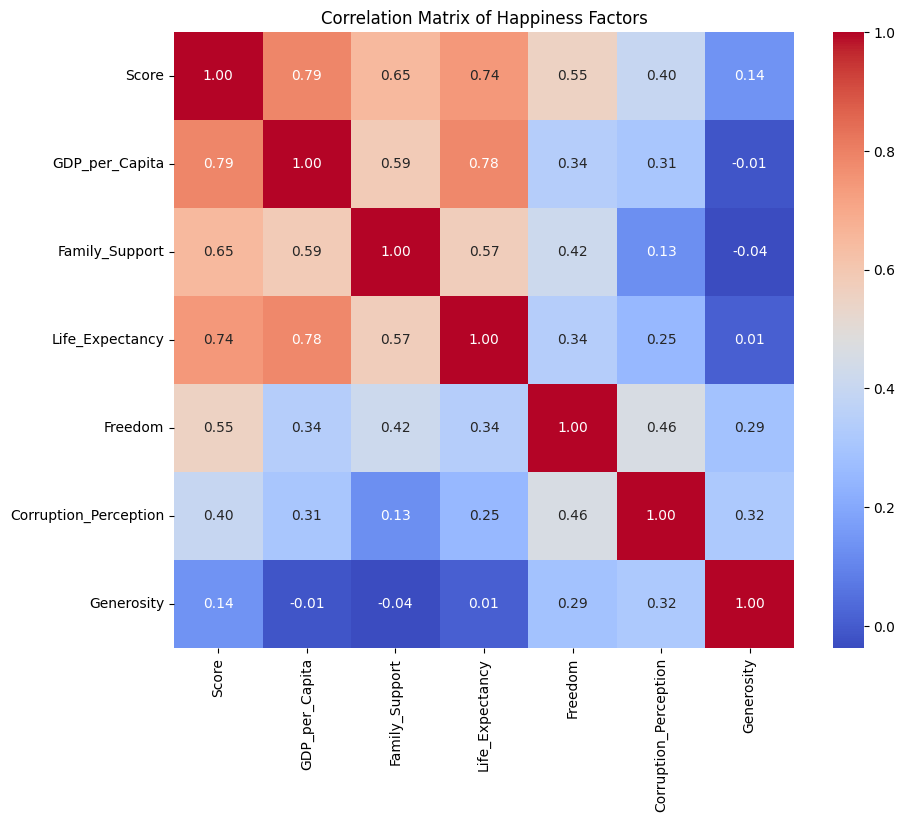

In [10]:
# Display the correlation matrix
plt.figure(figsize=(10,8))
corralations=df[['Score', 'GDP_per_Capita', 'Family_Support','Life_Expectancy',
               'Freedom', 'Corruption_Perception', 'Generosity']].corr()
sns.heatmap(corralations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Happiness Factors")
plt.show()

/tmp/ipykernel_13552/3620523316.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=values, y=labels, palette=palette)


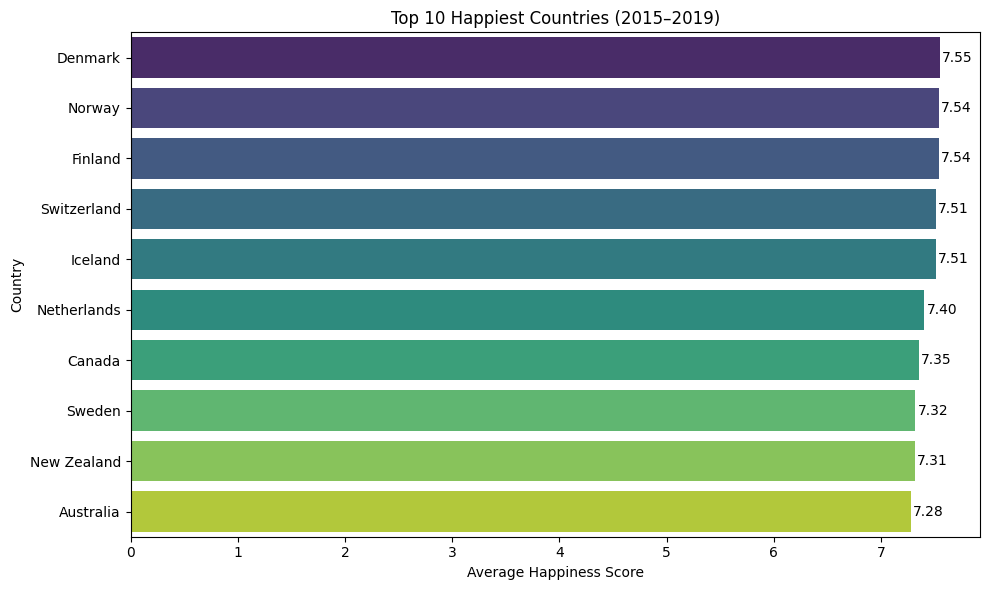

In [11]:
# Top 10 happiest countries
top_10_happiest = df.groupby('Country')['Score'].mean().sort_values(ascending=False).head(10)

# Prepare data for plotting
top_10_happiest = top_10_happiest.reset_index()
top_10_happiest.columns = ['Country', 'Average_Score']

# Labels
xlabel = 'Average Happiness Score'
ylabel = 'Country'
title = 'Top 10 Happiest Countries (2015–2019)'

# Plotting
bar_plot(labels=top_10_happiest['Country'],
          values=top_10_happiest['Average_Score'],
         title=title,
          xlabel=xlabel, 
          ylabel=ylabel,
          annotate=True,
           orient='h', 
           palette='viridis'
          )

The plot shows the Top 10 Happiest Countries (2015–2019) based on the average happiness score.
Denmark ranks highest, followed closely by Norway and Finland. Most of the countries in the top 10 are Scandinavian nations, except for Canada, New Zealand, and Australia. This indicates a regional trend, where Northern European countries consistently maintain high happiness levels over multiple years.

/tmp/ipykernel_13552/3620523316.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=values, y=labels, palette=palette)


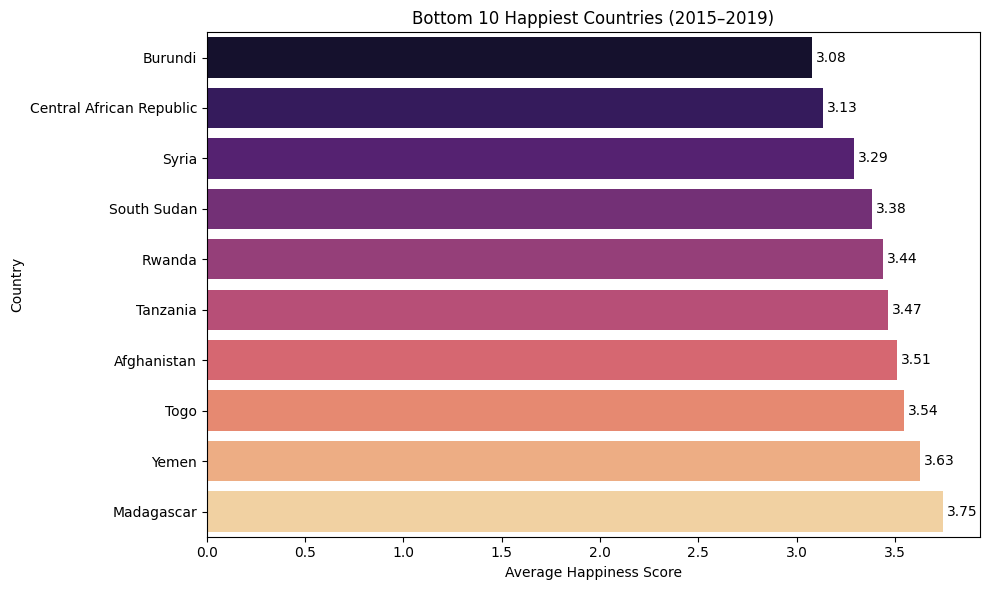

In [12]:
# bottom 10 happiest countries
bottom_10_happiest = df.groupby('Country')['Score'].mean().sort_values(ascending=True).head(10)

# Prepare data for plotting
bottom_10_happiest = bottom_10_happiest.reset_index()
bottom_10_happiest.columns = ['Country', 'Average_Score']

# Labels
xlabel = 'Average Happiness Score'
ylabel = 'Country'
title = 'Bottom 10 Happiest Countries (2015–2019)'
# Plotting
bar_plot(labels=bottom_10_happiest['Country'],
            values=bottom_10_happiest['Average_Score'],
            title=title,
            xlabel=xlabel,
            ylabel=ylabel,
            annotate=True,
            orient='h',
            palette='magma')


This bar plot shows the 10 least happy countries based on the average happiness score from 2015 to 2019. Burundi ranks as the least happy country, followed by the Central African Republic and Syria. Most countries in the list are from Africa and the Middle East, suggesting that political instability and economic challenges may contribute to lower happiness levels.

The line plot shows the average happiness score by year (2015–2019). The score reaches its highest value in 2019 and its lowest in 2017, suggesting that global conditions in 2017 may have negatively affected overall happiness.

/tmp/ipykernel_13552/494039292.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Year',y='Score',palette='magma')


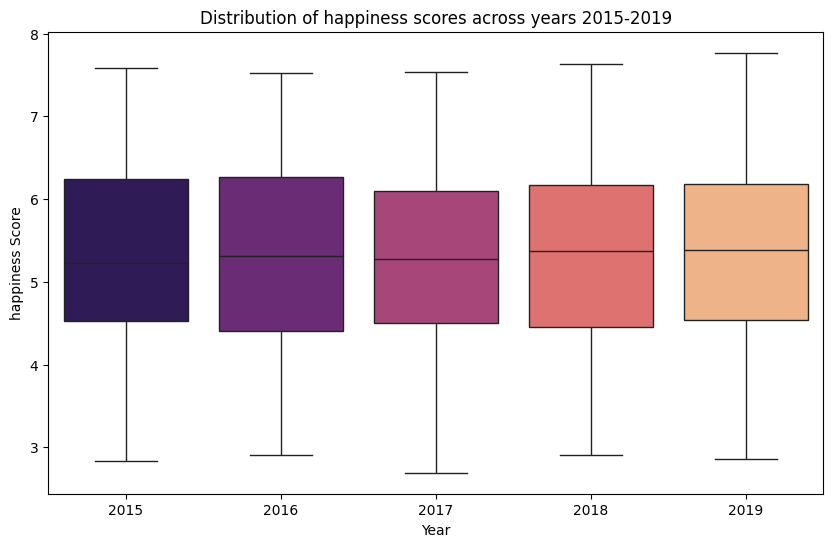

In [13]:
# display the distribution of happiness scores across all years using box plot

plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Year',y='Score',palette='magma')
plt.title('Distribution of happiness scores across years 2015-2019')
plt.xlabel('Year')
plt.ylabel('happiness Score')
plt.show()

The box plots shows that 2019 has the highest median happiness score, while 2015 has the lowest median happiness score. Additionally, 2019 has a wider interquartile range compared to other years, indicating more variability in happiness scores among countries in that year.

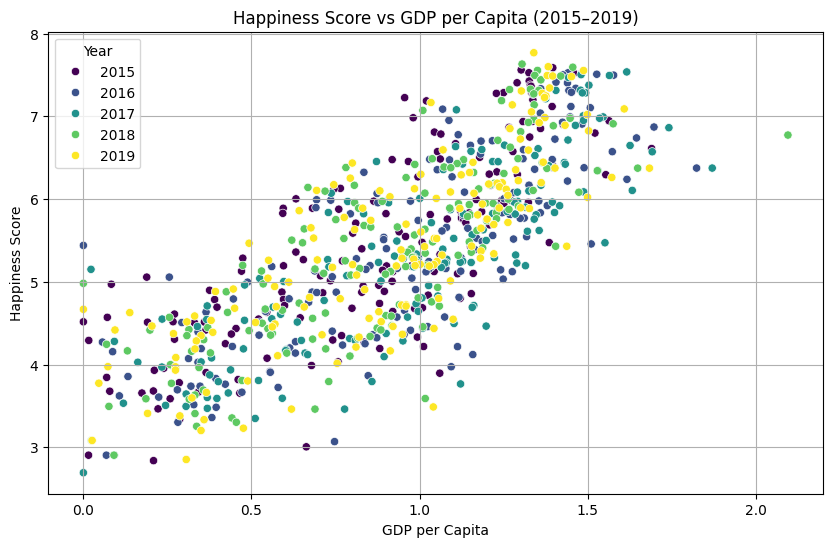

In [14]:
# display the distribution of happiness scores by GDP per capita across all years
plt.figure(figsize=(10,6))
sns.scatterplot(x='GDP_per_Capita', y='Score', data=df, hue='Year', palette='viridis')
plt.title('Happiness Score vs GDP per Capita (2015–2019)')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.legend(title='Year')
plt.grid()
plt.show()


The scatter plot shows the relationship between GDP per Capita and happiness score across all years from 2015 to 2019. The relationship is positive, indicating that countries with higher GDP per Capita 
tend to report higher happiness scores.

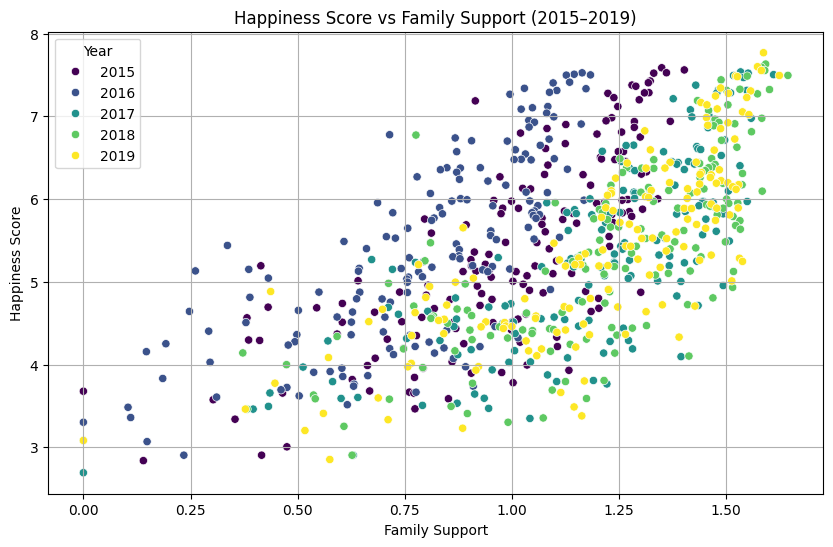

In [15]:
# display the distribution of happiness scores by Family Support across all years
plt.figure(figsize=(10,6))
sns.scatterplot(x='Family_Support', y='Score', data=df, hue='Year', palette='viridis')
plt.title('Happiness Score vs Family Support (2015–2019)')
plt.xlabel('Family Support')
plt.ylabel('Happiness Score')
plt.legend(title='Year')
plt.grid()
plt.show()

The scatter plot shows a positive correlation between family support and happiness score, Indicating that countries with highest levels of family support tends to have higher happiness scores, thit suggests that strong social connections and support systems may play a significant role in contributing to overall happiness in the country.

<Figure size 1000x600 with 0 Axes>

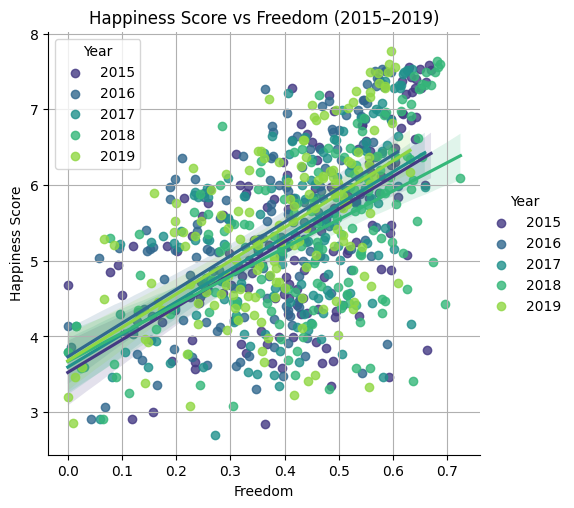

In [23]:
# display the distribution of happiness scores by Freedom 
plt.figure(figsize=(10,6))
sns.lmplot(x='Freedom', y='Score', data=df, hue='Year', palette='viridis')
plt.title('Happiness Score vs Freedom (2015–2019)')
plt.xlabel('Freedom')
plt.ylabel('Happiness Score')
plt.legend(title='Year')
plt.grid()
plt.show()

The regplot shows a positive correlation between freedom and happiness score, indicating that higher levels of freedom are associated with higher happiness scores.

<Figure size 1000x600 with 0 Axes>

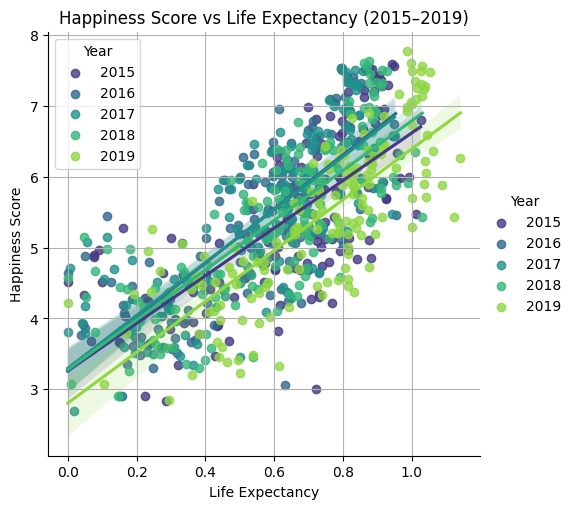

In [22]:
# Display the distribution of happiness scores by life expectancy across all years using regression plot
plt.figure(figsize=(10,6))
sns.lmplot(x='Life_Expectancy', y='Score', data=df, hue='Year', palette='viridis')
plt.title('Happiness Score vs Life Expectancy (2015–2019)')
plt.xlabel('Life Expectancy')
plt.ylabel('Happiness Score')
plt.legend(title='Year')
plt.grid()
plt.show()


The regression plot shows a positive correlation between life expectancy and happiness score, indicating that countries with higher life expectancy tend to have higher happiness scores.

<Figure size 1000x600 with 0 Axes>

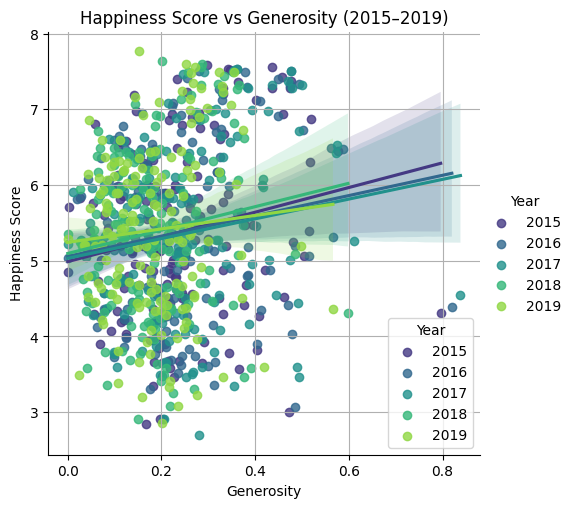

In [20]:
# Display the distribution of happiness scores by Generosity across all years using regression plot
plt.figure(figsize=(10,6))
sns.lmplot(x='Generosity', y='Score', data=df, hue='Year', palette='viridis')
plt.title('Happiness Score vs Generosity (2015–2019)')
plt.xlabel('Generosity')
plt.ylabel('Happiness Score')
plt.legend(title='Year')
plt.grid()
plt.show()


The regplot shows a weak positive correlation between Generosity and Happiness Score, suggesting that higher generosity may be associated with slightly higher happiness scores, but the relationship is not strong.

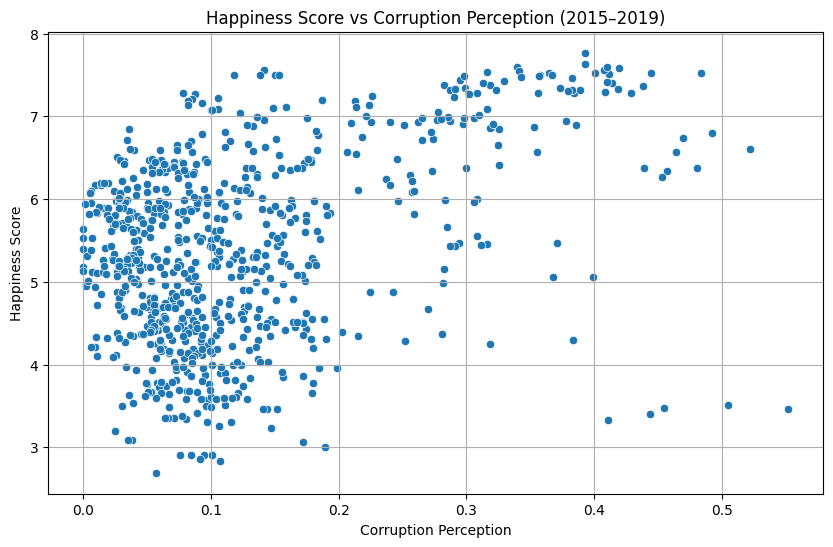

In [ ]:
# Display the distribution of happiness scores by Corruption Perception across all years using regression plot
plt.figure(figsize=(10,6))
sns.scatterplot(x='Corruption_Perception', y='Score', data=df)
plt.title('Happiness Score vs Corruption Perception (2015–2019)')
plt.xlabel('Corruption Perception')
plt.ylabel('Happiness Score')
plt.grid()
plt.show()

# The scatter plot shows a very weak positive correlation between Corruption Perception and Happiness Score, the points are widely scattered, indicating that Corruption Perception is not a strong predictor of Happiness Score in this dataset.

The scatter plot shows a very weak positive correlation between Corruption Perception and Happiness Score, the points are widely scattered, indicating that Corruption Perception is not a strong predictor of Happiness Score in this dataset.

### ***Save Data ***

In [25]:
# save the combined dataset to a new CSV file
df.to_csv('data/combined_world_happiness_data.csv', index=False)


Conclusion:
The analysis of the World Happiness Report data from 2015 to 2019 reveals several key insights into the factors that contribute to happiness across different countries. The correlation matrix indicates that GDP per capita, family support, life expectancy, freedom, and generosity are all positively correlated with happiness scores,  
suggesting that these factors play a significant role in determining the overall happiness of a population. The top 10 happiest countries consistently show high scores in these areas, while the bottom 10 happiest countries tend to have lower scores, particularly in GDP per capita and family support. The regression plots further illustrate the positive relationships between happiness scores and these key factors, reinforcing the importance of economic prosperity, social support, health, and personal freedoms in fostering happiness. However, corruption perception appears to have a weak correlation with happiness scores, indicating that it may not be a primary driver of happiness in this dataset. Overall, this analysis highlights the multifaceted nature of happiness and underscores the importance of addressing various social and economic factors to improve well-being globally.
